In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [4]:
data = pd.read_csv(r"AirPassengers.csv")
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
data.head()


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
result = adfuller(data["#Passengers"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: 0.8153688792060597
p-value: 0.9918802434376411


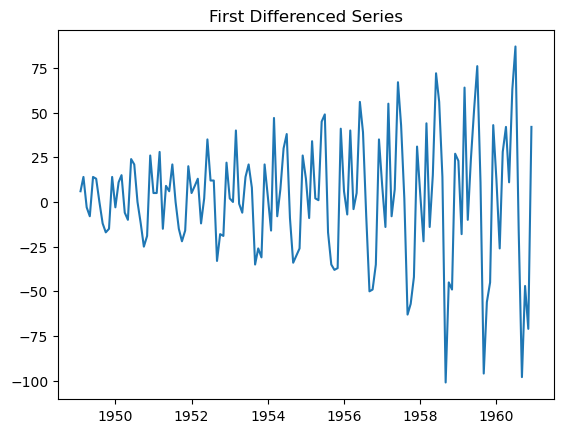

p-value: 0.0542132902838265


In [6]:
data_diff = data['#Passengers'].diff().dropna()
#Plot Differenced Series
plt.figure()
plt.plot(data_diff)
plt.title('First Differenced Series')
plt.show()
#ADF Test Again
Res=adfuller(data_diff)
print("p-value:", Res[1])


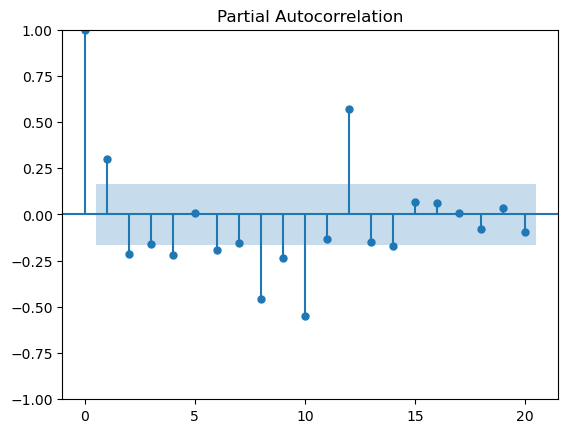

In [7]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plot_pacf(data_diff, lags=20)
plt.show()


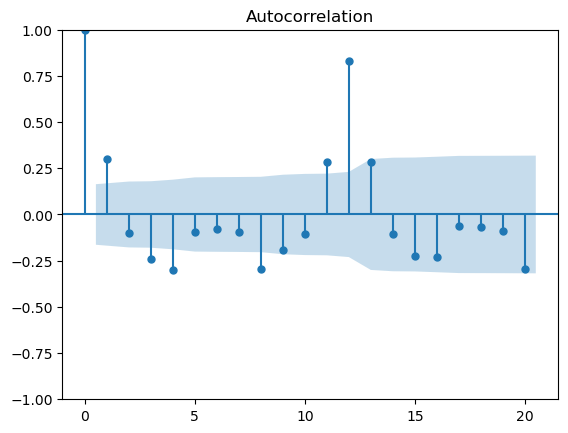

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(data_diff, lags=20)
plt.show()


In [10]:
model = ARIMA(data['#Passengers'], order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Tue, 03 Feb 2026   AIC                           1394.683
Time:                        08:51:00   BIC                           1403.571
Sample:                    01-01-1949   HQIC                          1398.294
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [11]:
forecast = model_fit.forecast(steps=48)
print(forecast)


1961-01-01    475.735059
1961-02-01    454.996073
1961-03-01    464.830415
1961-04-01    460.167010
1961-05-01    462.378378
1961-06-01    461.329756
1961-07-01    461.827008
1961-08-01    461.591213
1961-09-01    461.703026
1961-10-01    461.650005
1961-11-01    461.675148
1961-12-01    461.663225
1962-01-01    461.668879
1962-02-01    461.666198
1962-03-01    461.667469
1962-04-01    461.666866
1962-05-01    461.667152
1962-06-01    461.667017
1962-07-01    461.667081
1962-08-01    461.667050
1962-09-01    461.667065
1962-10-01    461.667058
1962-11-01    461.667061
1962-12-01    461.667060
1963-01-01    461.667060
1963-02-01    461.667060
1963-03-01    461.667060
1963-04-01    461.667060
1963-05-01    461.667060
1963-06-01    461.667060
1963-07-01    461.667060
1963-08-01    461.667060
1963-09-01    461.667060
1963-10-01    461.667060
1963-11-01    461.667060
1963-12-01    461.667060
1964-01-01    461.667060
1964-02-01    461.667060
1964-03-01    461.667060
1964-04-01    461.667060


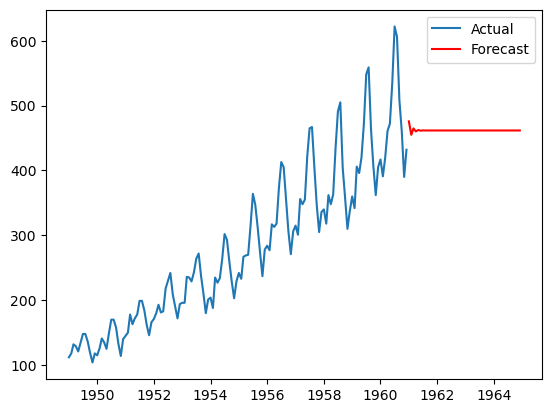

In [12]:
plt.figure()
plt.plot(data['#Passengers'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()
